In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
resnet_metrics = pd.read_csv(
    "/kaggle/input/datasets/mistblade69/metrics/resnet_evaluation_metrics.csv"
)

mobilenet_metrics = pd.read_csv( "/kaggle/input/datasets/mistblade69/metrics/mobilenet_evaluation_metrics.csv"
)

print("Metrics read Successfully")

Metrics read Successfully


In [3]:
resnet_dict = dict(
    zip(
        resnet_metrics["Metric"],
        resnet_metrics["Value"]
    )
)

mobilenet_dict = dict(
    zip(
        mobilenet_metrics["Metric"],
        mobilenet_metrics["Value"]
    )
)

In [4]:
resnet_params = 24121476
mobilenet_params = 2592068

resnet_inference_time = 0.07732774686813354
mobilenet_inference_time = 0.2182369658946991

In [5]:
comparison_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Relative Parameters",
        "Relative Inference Time"
    ],

    "ResNet": [
        resnet_dict["Accuracy"],
        resnet_dict["Precision"],
        resnet_dict["Recall"],
        resnet_dict["F1 Score"],
        resnet_dict["ROC-AUC"],
        resnet_params,
        resnet_inference_time
    ],

    "MobileNetV2": [
        mobilenet_dict["Accuracy"],
        mobilenet_dict["Precision"],
        mobilenet_dict["Recall"],
        mobilenet_dict["F1 Score"],
        mobilenet_dict["ROC-AUC"],
        mobilenet_params,
        mobilenet_inference_time
    ]
})

comparison_df

,Metric,ResNet,MobileNetV2
0,Accuracy,9.340000e-01,8.540000e-01
1,Precision,9.384723e-01,8.648546e-01
2,Recall,9.340000e-01,8.540000e-01
3,F1 Score,9.337159e-01,8.508505e-01
4,ROC-AUC,9.952800e-01,9.811162e-01
5,Relative Parameters,2.412148e+07,2.592068e+06
6,Relative Inference Time,7.732775e-02,2.182370e-01


In [6]:
comparison_df.to_csv(
    "/kaggle/working/final_model_comparison.csv",
    index=False
)

print("Final comparison CSV saved.")

Final comparison CSV saved.


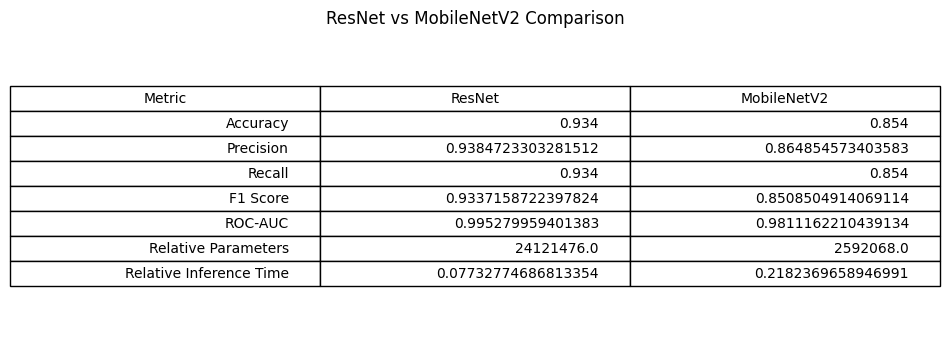

In [7]:
fig, ax = plt.subplots(figsize=(10,4))

ax.axis('off')

table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title(
    "ResNet vs MobileNetV2 Comparison"
)

plt.savefig(
    "/kaggle/working/final_comparison_table.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [8]:
plot_df = comparison_df.copy()

large_metrics = [
    "Relative Parameters",
    "Relative Inference Time"
]

for metric in large_metrics:

    max_value = plot_df.loc[
        plot_df["Metric"] == metric,
        ["ResNet", "MobileNetV2"]
    ].values.max()

    plot_df.loc[
        plot_df["Metric"] == metric,
        ["ResNet", "MobileNetV2"]
    ] = (
        plot_df.loc[
            plot_df["Metric"] == metric,
            ["ResNet", "MobileNetV2"]
        ] / max_value
    )

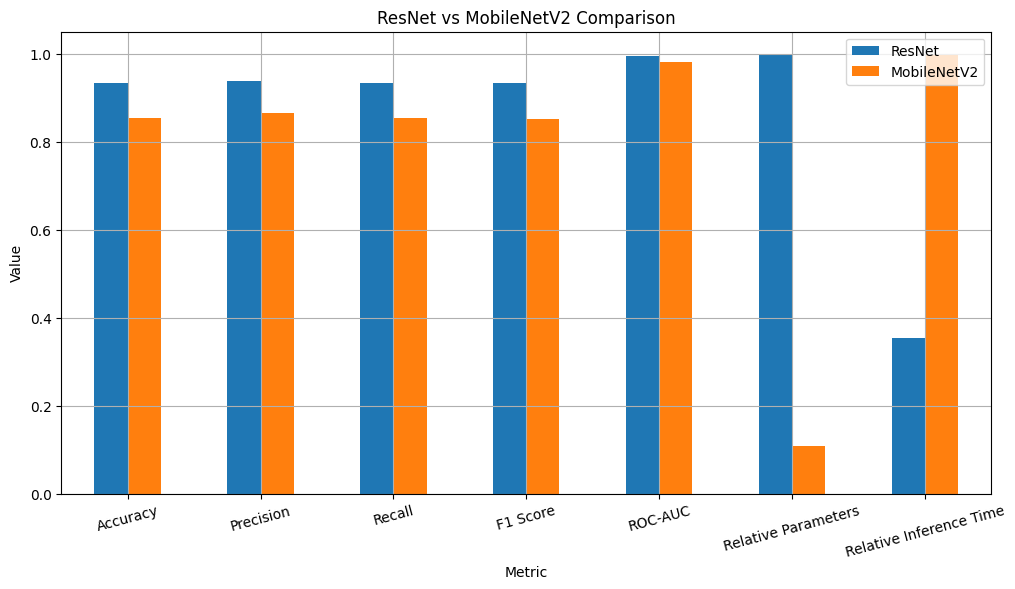

In [9]:
plot_df.plot(
    x="Metric",
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "ResNet vs MobileNetV2 Comparison"
)

plt.ylabel("Value")

plt.grid(True)

plt.xticks(rotation=15)

plt.savefig(
    "/kaggle/working/better_comparison_graph.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()